In [1]:
%pip install jupyterlab

  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 120.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 154.6 MB/s  0:00:00
Using cached idna-3.18-py3-none-any.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.6/806.6 kB 8.5 MB/s  0:00:00
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42/42 [jupyterlab]pyterlab]pyter-lsp]erver]]
Note: y

In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn.utils import parameters_to_vector
from torch.nn.functional import gelu
# from torchvision import datasets, transforms

# import torchattacks

import numpy as np
import matplotlib.pyplot as plt
# from tqdm import tqdm

from copy import deepcopy
# from itertools import permutations

from helpers import *

# import plotly.express as px
# import plotly.graph_objects as go
# import plotly.io as pio

# import matplotlib.animation as animation
# from matplotlib.colors import ListedColormap

from collections import deque
from torch.utils.data import TensorDataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


In [2]:
%config InlineBackend.figure_format = 'png'

# Use this for Windows
device = "cuda" if torch.cuda.is_available() else "cpu"

/projects/b1042/AmaralLab/shin/DNN-Decision-Uncertainty-Quantification/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Functions

In [3]:
def multilabel_hypersphere_data(dim_in, dim_out, N_samples, batch_size, seed):
    """
    Generates N-dimensional hypersphere multilabeling problem data.

    dim_out is a vector of 2 elements.
    Total dim_out classes = the first + second ele

    Unit vector directions are drawn from standard normal in dim_in dimensions.
    Then vectors are scaled uniformly by radius 0 < r < 1.
    Radii are assigned to the first element of dim_out classes with overlapping,
    and the second element of dim_out classes splits the circle in 2n pizza slices,
    then adds new labels on points in every other slice.

    Function returns DataLoader class containing generated samples.
    """
    torch.manual_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    u = torch.randn(N_samples, dim_in, generator=g)
    u = u / torch.linalg.vector_norm(u, dim=1).unsqueeze(1)

    angle_rad = torch.atan2(u[:,1], u[:,0])

    r = torch.sqrt(torch.rand(N_samples, generator=g))
    data = u * r.unsqueeze(1) # Scale unit directions by radii

    # Evenly divide radii into classes by cicle and slices, [N_samples,1]
    sections = torch.bucketize(r, torch.linspace(0, 1, dim_out[0]*2)) - 1
    pizza = torch.bucketize(angle_rad, torch.linspace(-torch.pi, torch.pi, dim_out[1]*2+1)) - 1

    labels = torch.zeros(N_samples, dim_out[0] + dim_out[1])

    # Assign labels for the first element of dim_out classes based on sections
    for j in range(max(sections)+1):
        if j%2==0:
            labels[sections == j, j//2] = 1
        elif j//2+1 < dim_out[0]:
            labels[sections == j, j//2] = 1
            labels[sections == j, j//2 + 1] = 1

    # Assign labels for the second element of dim_out classes based on pizza slices
    for i in range(max(pizza)+1):
        if i%2==0:
            labels[:, dim_out[0] + i//2] = (pizza==i).int()
    
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(TensorDataset(data, labels), 
                      batch_size=batch_size, shuffle=True, generator=g)

In [ ]:
def shannon_stability_multilabel(cat_all, cats):   
    # cat_all.shape = (len(X), output_dim)
    # get % of a class being classified as positive for a point
    cat_all = cat_all / cats

    # stability of each class (binary prob) for each point on grid from Shannon formula (len(X), output_dim)
    # elementwise mult -> cat_all * torch.log(cat_all + 1e-10) 
    stabilities = 1 + (cat_all * torch.log(cat_all + 1e-10) + (1 - cat_all) * torch.log(1 - cat_all + 1e-10)) / np.log(2)
    stability = stabilities.mean(dim=1)

    return stability.detach().cpu().numpy()

In [6]:
def find_best_thresholds(probs, labels, thresholds=np.arange(0.05, 0.95, 0.05)):
    """probs, labels: (N, num_classes) numpy arrays"""
    best_thresholds = np.zeros(probs.shape[1])
    for c in range(probs.shape[1]):
        best_f1, best_t = 0, 0.5
        for t in thresholds:
            preds_c = (probs[:, c] > t).astype(int)
            f1 = f1_score(labels[:, c], preds_c, zero_division=0, average="micro")
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds[c] = best_t

    # returns best thresholds for each class (output_dim,)
    return best_thresholds

In [ ]:
# train model - stability calculated with only the last 100 trainings
def train_model(seed, hidden_dim, n_epochs, batch_size, amount_data, data=hypersphere_data,
                cat100=True, input_dim=2, output_dim=[2,2], num_points_per_dim=100, history_limit = 100):
    train_loader = data(input_dim, output_dim, amount_data, 
                                    batch_size = batch_size, seed = seed)    
    torch.manual_seed(seed)

    numlabels = sum(output_dim)
    model = MLP((input_dim, *hidden_dim, numlabels), bias=True, activation = nn.GELU)
    model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=5e-3)

    X, y = next(iter(data(input_dim, output_dim, num_points_per_dim**input_dim, 
                                    batch_size = num_points_per_dim**input_dim, seed = 0)))

    cat_all = torch.zeros(len(X), numlabels).to(device)
    loss_history = []

    # start calculating cat_all for the last 100 iterations
    total_iterations = n_epochs * len(train_loader)
    target_iteration = total_iterations - history_limit if history_limit is not None else 0

    itr = 0

    for _ in range(n_epochs):
        for data, target in train_loader:
            itr += 1    
            data, target = data.to(device), target.to(device)

            outputs = model(data)
            loss = criterion(outputs, target)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                if cat100==False or itr > target_iteration:
                    logits = model(X)                          # (N, numlabels), on device
                    prob = torch.sigmoid(logits).detach()        # keep as tensor, on device

                    threshold = find_best_thresholds(prob.cpu().numpy(), y.cpu().numpy())  # (numlabels,)
                    threshold_t = torch.as_tensor(threshold, dtype=prob.dtype, device=prob.device)

                    decision = (prob > threshold_t).to(cat_all.dtype)   # stays on device, matches cat_all dtype
                    cat_all += decision
                
    # Calculate your stability based on the rolling 100-step history (or not)
    stab = shannon_stability_multilabel(cat_all, history_limit)

    return model, stab, cat_all

In [74]:
def plot_softmax_2D(model, data=hypersphere_data, num_points_per_dim=100, output_dim=(2,2), seed=10):
    pt, lab = next(iter(data(2, output_dim, num_points_per_dim**2, batch_size = num_points_per_dim**2, seed = seed)))
    logits = model(pt) # (N,sum(output_dim))
    prob = torch.softmax(logits, dim=1).detach()

    best_thresholds = find_best_thresholds(prob.numpy(), lab.numpy()) # (sum(output_dim), )

    dist = np.abs(prob.numpy()-best_thresholds.T) # (N,sum(output_dim))
    probs = dist/np.max(dist) # (N,sum(output_dim))
    mean_prob = np.mean(probs, axis=1) # (N,)

    y_true = lab.numpy().astype(int)
    y_pred = (prob.numpy() > best_thresholds.T).astype(int)

    # calculate sample-wise F1 score for each point
    tp = (y_true & y_pred).sum(axis=1)
    fp = ((1 - y_true) & y_pred).sum(axis=1)
    fn = (y_true & (1 - y_pred)).sum(axis=1)
    denom = 2*tp + fp + fn
    f1 = np.divide(2*tp, denom, out=np.zeros(len(denom), dtype=float), where=denom != 0)  # (N,)

    print("probs shape:", probs.shape)
    print("probs median:", np.median(probs))
    print("mean_prob shape:", mean_prob.shape)
    
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.flatten()
    
    # plot a heat map based on the confidence given by the softmax in the input space
    axs[0].scatter(pt[:,0], pt[:,1], s=1, c=mean_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[0].collections[0], ax=axs[0])
    axs[0].set_title("Confidence from dist of softmax and threshold")

    # plot mean_prob vs sample-wise f1 score
    # lab [N, sum(output_dim)], prob [N, sum(output_dim)]
    # f1 = f1_score(lab.numpy(), (prob.numpy() > best_thresholds.T).astype(int), average="samples")
    axs[1].scatter(mean_prob, f1, s=1, alpha=0.9)
    axs[1].set_xlabel("Mean softmax confidence per point")
    axs[1].set_ylabel("Sample-wise F1 per point")
    axs[1].set_title("Softmax confidence vs F1 score")

    # plot the distribution of probs
    axs[2].hist(probs.flatten(), bins=50, alpha=0.7)
    axs[2].set_xlabel("Confidence from softmax")
    axs[2].set_ylabel("Frequency")
    axs[2].set_title("Distribution of Confidence from softmax")

    # plot a heat map based on the max softmax value for each point
    max_prob = np.max(prob.numpy(), axis=1) # (N,)
    axs[3].scatter(pt[:,0], pt[:,1], s=1, c=max_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[3].collections[0], ax=axs[3])
    axs[3].set_title("Max softmax value per point")

    # plot a heat map based on the mean softmax value greater than the best threshold for each point
    mask = prob.numpy() > best_thresholds.T
    p = prob.numpy()
    sums = np.where(mask, p, 0).sum(axis=1)
    counts = mask.sum(axis=1)
    mean_active_prob = np.divide(sums, counts, out=np.zeros(len(counts)), where=counts != 0)  # (N,), 0 where nothing passed

    axs[4].scatter(pt[:,0], pt[:,1], s=1, c=mean_active_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[4].collections[0], ax=axs[4])
    axs[4].set_title("Mean softmax value above threshold per point")

    # plot a heat map based on the f1 score for each point
    axs[5].scatter(pt[:,0], pt[:,1], s=1, c=f1, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[5].collections[0], ax=axs[5])
    axs[5].set_title("Sample-wise F1 score per point")
    
    plt.tight_layout()
    plt.savefig(f"plots/softmax_confidence_vs_f1_{output_dim[0]}x{output_dim[1]}.png", dpi=300)

    # calculate and print f1 score for each class 
    print("F1 scores per class:")
    f1_per_class = []
    for c in range(prob.shape[1]):
        f1_c = f1_score(y_true[:, c], y_pred[:, c], zero_division=0, average="micro")
        f1_per_class.append(f1_c)
        print(f"Class {c}: F1 score = {f1_c:.4f}")

    # print thresholds for each class
    print(f"Best thresholds per class: {best_thresholds}")

    # visualize decision boundaries for each class (softmax)
    fig, axs = plt.subplots(1, prob.shape[1], figsize=(4*prob.shape[1], 4))
    for c in range(prob.shape[1]):
        axs[c].scatter(pt[:,0], pt[:,1], s=1, c=prob[:,c], cmap="Spectral", alpha=0.9)
        axs[c].set_title(f"Class {c} softmax value")
        axs[c].set_xlabel("X-axis")
        axs[c].set_ylabel("Y-axis")
        fig.colorbar(axs[c].collections[0], ax=axs[c])

    plt.tight_layout()
    plt.savefig(f"plots/softmax_decision_boundaries_{output_dim[0]}x{output_dim[1]}.png", dpi=300)

    # visualize decision boundaries for each class (confidence?)
    fig, axs = plt.subplots(1, probs.shape[1], figsize=(4*probs.shape[1], 4))
    for c in range(probs.shape[1]):
        axs[c].scatter(pt[:,0], pt[:,1], s=1, c=probs[:,c], cmap="Spectral", alpha=0.9)
        axs[c].set_title(f"Class {c} confidence from softmax")
        axs[c].set_xlabel("X-axis")
        axs[c].set_ylabel("Y-axis")
        fig.colorbar(axs[c].collections[0], ax=axs[c])

    plt.tight_layout()
    plt.savefig(f"plots/softmax_confidence_{output_dim[0]}x{output_dim[1]}.png", dpi=300)
     

In [75]:
def plot_sigmoid_2D(model, data=hypersphere_data, num_points_per_dim=100, output_dim=(2,2), seed=10):
    pt, lab = next(iter(data(2, output_dim, num_points_per_dim**2, batch_size = num_points_per_dim**2, seed = seed)))
    logits = model(pt) # (N,sum(output_dim))
    prob = torch.sigmoid(logits).detach() # (N,sum(output_dim))

    best_thresholds = find_best_thresholds(prob.numpy(), lab.numpy()) # (sum(output_dim), 1)

    dist = np.abs(prob.numpy()-best_thresholds.T) # (N,sum(output_dim))
    probs = dist/np.max(dist) # (N,sum(output_dim))
    mean_prob = np.mean(probs, axis=1) # (N,)

    y_true = lab.numpy().astype(int)
    y_pred = (prob.numpy() > best_thresholds.T).astype(int)

    # calculate sample-wise F1 score for each point
    tp = (y_true & y_pred).sum(axis=1)
    fp = ((1 - y_true) & y_pred).sum(axis=1)
    fn = (y_true & (1 - y_pred)).sum(axis=1)
    denom = 2*tp + fp + fn
    f1 = np.divide(2*tp, denom, out=np.zeros(len(denom), dtype=float), where=denom != 0)  # (N,)

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.flatten()

    # plot a heat map based on the confidence given by the sigmoid in the input space
    axs[0].scatter(pt[:,0], pt[:,1], s=1, c=mean_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[0].collections[0], ax=axs[0])
    axs[0].set_title("Confidence given by the dist of sigmoid and threshold")

    # plot mean_prob vs sample-wise f1 score
    # lab [N, sum(output_dim)], prob [N, sum(output_dim)]
    # f1 = f1_score(lab.numpy(), (prob.numpy() > best_thresholds.T).astype(int), average="samples")
    axs[1].scatter(mean_prob, f1, s=1, alpha=0.9)
    axs[1].set_xlabel("Mean confidence")
    axs[1].set_ylabel("Sample-wise F1")
    axs[1].set_title("Mean sigmoid confidence vs F1 score")

    # plot the distribution of probs
    axs[2].hist(probs.flatten(), bins=50, alpha=0.7)
    axs[2].set_xlabel("Confidence from sigmoid")
    axs[2].set_ylabel("Frequency")
    axs[2].set_title("Distribution of Confidence from sigmoid")

    # plot a heat map based on the max softmax value for each point
    max_prob = np.max(prob.numpy(), axis=1) # (N,)
    axs[3].scatter(pt[:,0], pt[:,1], s=1, c=max_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[3].collections[0], ax=axs[3])
    axs[3].set_title("Max sigmoid value per point")

    # plot a heat map based on the mean sigmoid value greater than the best threshold for each point
    mask = prob.numpy() > best_thresholds.T
    p = prob.numpy()
    sums = np.where(mask, p, 0).sum(axis=1)
    counts = mask.sum(axis=1)
    mean_active_prob = np.divide(sums, counts, out=np.zeros(len(counts)), where=counts != 0)  # (N,), 0 where nothing passed
    axs[4].scatter(pt[:,0], pt[:,1], s=1, c=mean_active_prob, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[4].collections[0], ax=axs[4])
    axs[4].set_title("Mean sigmoid value above threshold per point")

    # plot a heat map based on the f1 score for each point
    axs[5].scatter(pt[:,0], pt[:,1], s=1, c=f1, cmap="Spectral", alpha=0.9)
    fig.colorbar(axs[5].collections[0], ax=axs[5])
    axs[5].set_title("Sample-wise F1 score per point")
    
    plt.tight_layout()
    plt.savefig(f"plots/sigmoid_confidence_vs_f1_{output_dim[0]}x{output_dim[1]}.png", dpi=300)

    # calculate and print f1 score for each class 
    print("F1 scores per class:")
    f1_per_class = []
    for c in range(prob.shape[1]):
        f1_c = f1_score(y_true[:, c], y_pred[:, c], zero_division=0, average="micro")
        f1_per_class.append(f1_c)
        print(f"Class {c}: F1 score = {f1_c:.4f}")

    # print thresholds for each class
    print(f"Best thresholds per class: {best_thresholds}")

    # visualize decision boundaries for each class (sigmoid)
    fig, axs = plt.subplots(1, prob.shape[1], figsize=(4*prob.shape[1], 4))
    for c in range(prob.shape[1]):
        axs[c].scatter(pt[:,0], pt[:,1], s=1, c=prob[:,c], cmap="Spectral", alpha=0.9)
        axs[c].set_title(f"Class {c} sigmoid value")
        axs[c].set_xlabel("X-axis")
        axs[c].set_ylabel("Y-axis")
        fig.colorbar(axs[c].collections[0], ax=axs[c])

    plt.tight_layout()
    plt.savefig(f"plots/sigmoid_decision_boundaries_{output_dim[0]}x{output_dim[1]}.png", dpi=300)

    # visualize decision boundaries for each class (confidence?)
    fig, axs = plt.subplots(1, probs.shape[1], figsize=(4*probs.shape[1], 4))
    for c in range(probs.shape[1]):
        axs[c].scatter(pt[:,0], pt[:,1], s=1, c=probs[:,c], cmap="Spectral", alpha=0.9)
        axs[c].set_title(f"Class {c} confidence from sigmoid")
        axs[c].set_xlabel("X-axis")
        axs[c].set_ylabel("Y-axis")
        fig.colorbar(axs[c].collections[0], ax=axs[c])

    plt.tight_layout()
    plt.savefig(f"plots/sigmoid_confidence_{output_dim[0]}x{output_dim[1]}.png", dpi=300)
    


In [80]:
def plot_stability_2D(stab, data=hypersphere_data, num_points_per_dim=100, output_dim=(2,2)):
    X, y = next(iter(data(2, output_dim, num_points_per_dim**2, 
                                        batch_size = num_points_per_dim**2, seed = 0)))
    # cat = model(X).argmax(dim=1)

    plt.figure(figsize = (4,3))
    # plot a heat map based on the stability in the input space
    plt.scatter(X[:,0], X[:,1], s=1, c=stab, cmap="Spectral", alpha=0.9)
    plt.colorbar()

    plt.title("Stability from Shannon Entropy")
    plt.show()

    print(f"Mean Stability: {np.mean(stab)}")

## Visualize Data

In [43]:
pt, lab = next(iter(multilabel_hypersphere_data(2, (3,2), 1000, batch_size = 1000, seed = 42)))

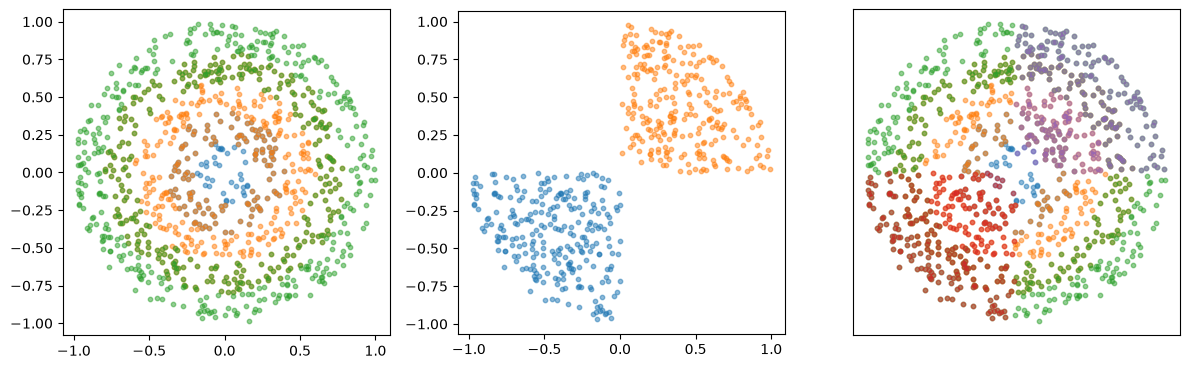

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax in axs:
    ax.set_aspect('equal')

axs[0].scatter(pt[lab[:,0] == 1, 0], pt[lab[:,0] == 1, 1], s=10, alpha=0.5)
axs[0].scatter(pt[lab[:,1] == 1, 0], pt[lab[:,1] == 1, 1], s=10, alpha=0.5)
axs[0].scatter(pt[lab[:,2] == 1, 0], pt[lab[:,2] == 1, 1], s=10, alpha=0.5)

axs[1].scatter(pt[lab[:,3] == 1, 0], pt[lab[:,3] == 1, 1], s=10, alpha=0.5)
axs[1].scatter(pt[lab[:,4] == 1, 0], pt[lab[:,4] == 1, 1], s=10, alpha=0.5)

axs[2].scatter(pt[lab[:,0] == 1, 0], pt[lab[:,0] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,1] == 1, 0], pt[lab[:,1] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,2] == 1, 0], pt[lab[:,2] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,3] == 1, 0], pt[lab[:,3] == 1, 1], s=10, alpha=0.5)
axs[2].scatter(pt[lab[:,4] == 1, 0], pt[lab[:,4] == 1, 1], s=10, alpha=0.5)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig("plots/multilabel_hypersphere_data_3x2.png", dpi=300)
plt.show()

In [91]:
model, stab, cat_all = train_model(42, (16,64,128), n_epochs=100, batch_size=100, amount_data=1000,
                                                      data=multilabel_hypersphere_data, cat100=True, input_dim=2, output_dim=(2,2),
                                                        num_points_per_dim=100, history_limit = 100)

In [92]:
cat_all/100

tensor([[0., 1., 1., 0.],
        [1., 1., 1., 0.],
        [1., 1., 0., 0.],
        ...,
        [0., 1., 0., 0.],
        [1., 1., 0., 1.],
        [0., 1., 1., 0.]])

probs shape: (10000, 4)
probs median: 0.052631578947368425
mean_prob shape: (10000,)
F1 scores per class:
Class 0: F1 score = 0.7969
Class 1: F1 score = 0.8763
Class 2: F1 score = 0.7605
Class 3: F1 score = 0.7651
Best thresholds per class: [0.05 0.05 0.05 0.05]


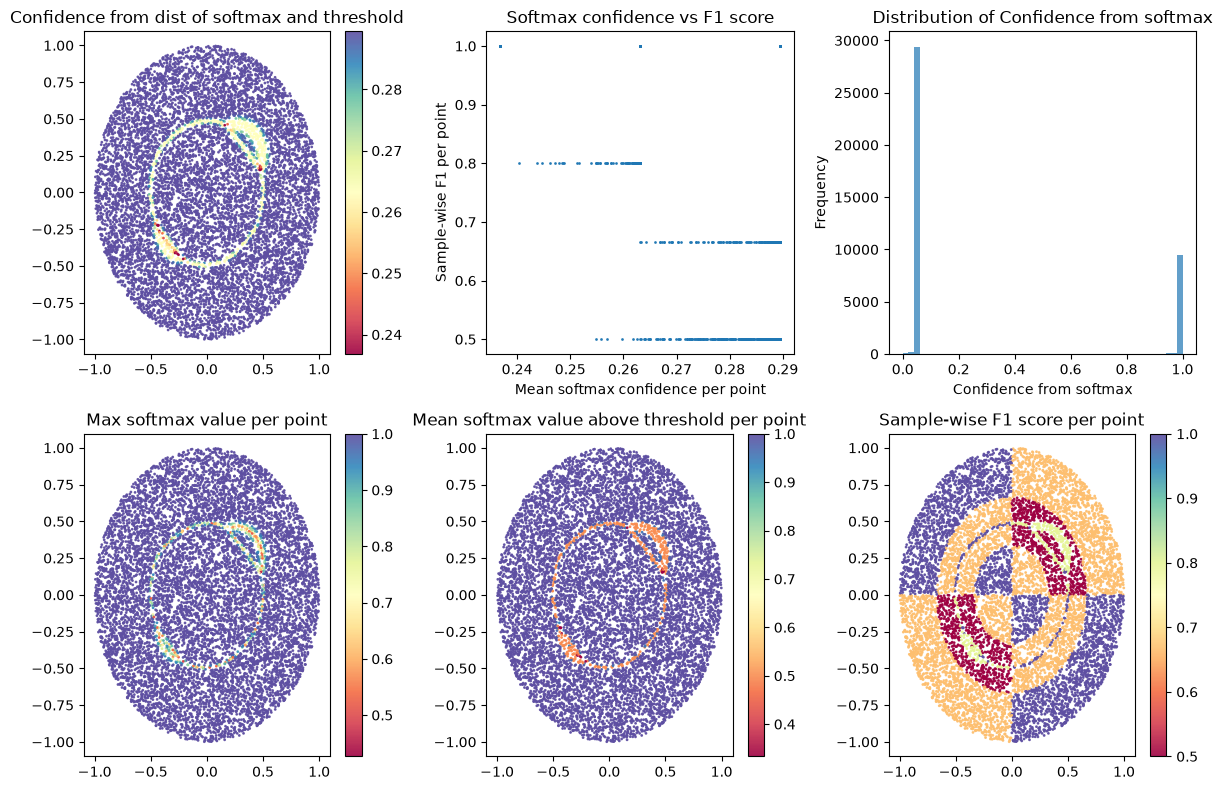

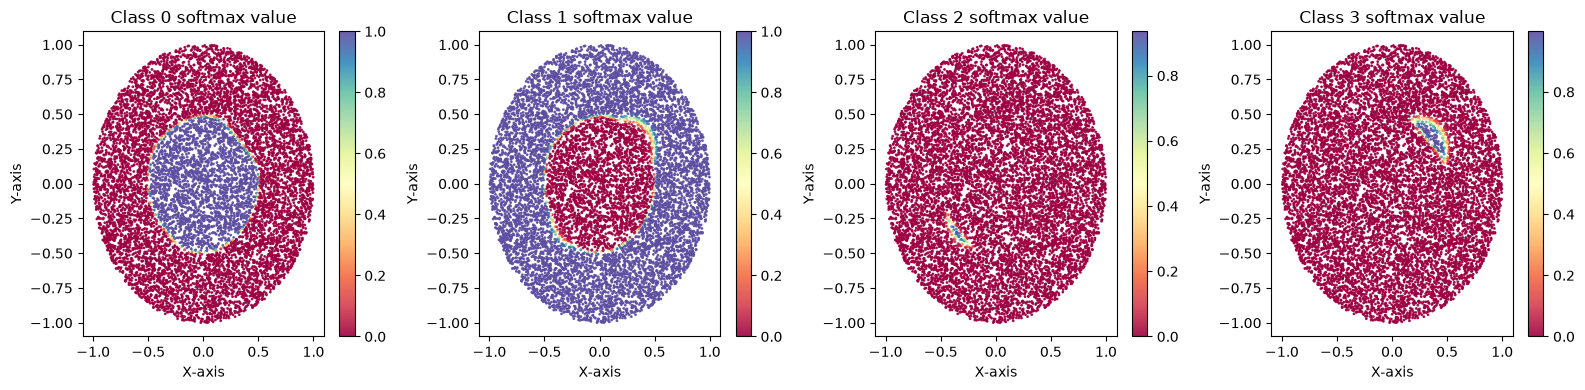

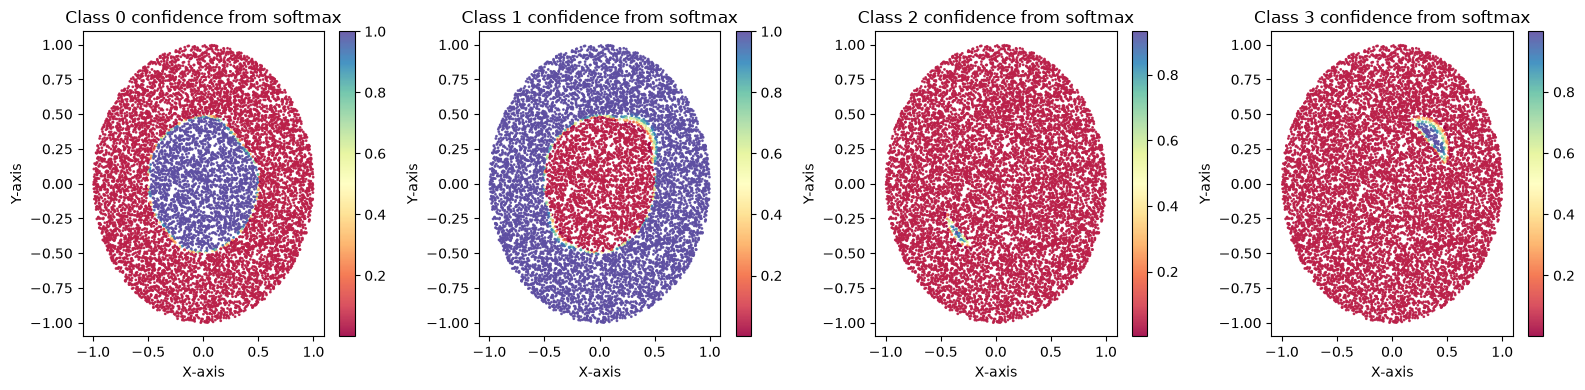

In [93]:
# plot softmax
plot_softmax_2D(model, data=multilabel_hypersphere_data, 
                num_points_per_dim=100, output_dim=(2,2), seed=42)

F1 scores per class:
Class 0: F1 score = 0.9924
Class 1: F1 score = 0.9947
Class 2: F1 score = 0.9971
Class 3: F1 score = 0.9943
Best thresholds per class: [0.8  0.4  0.85 0.85]


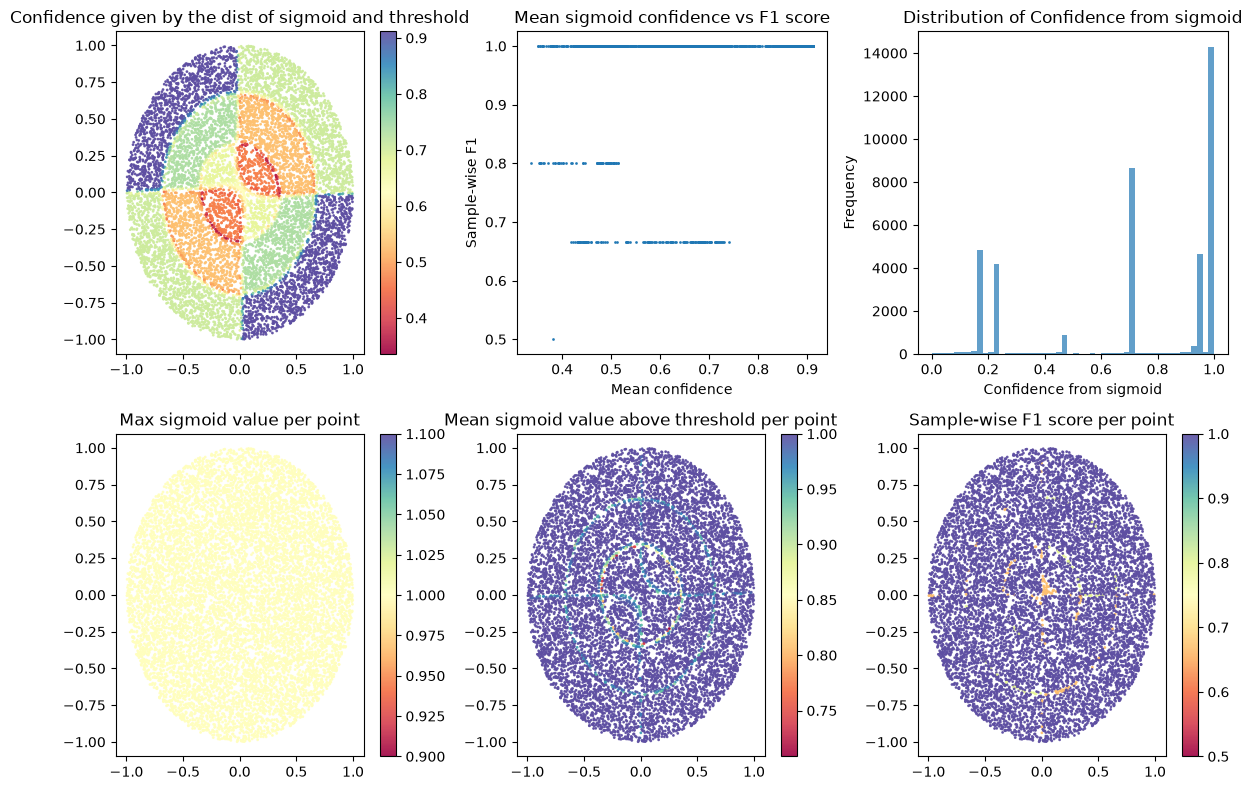

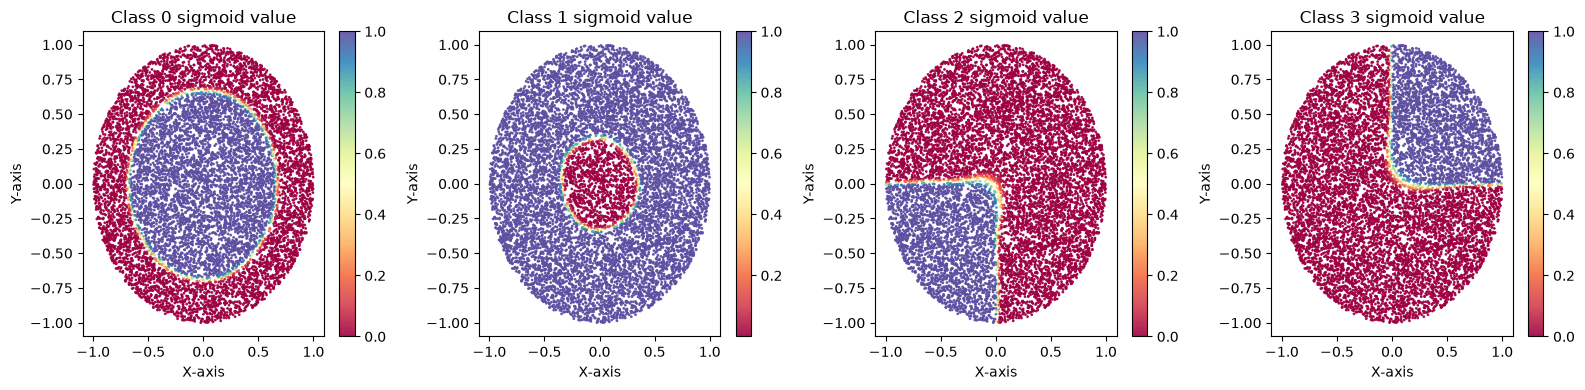

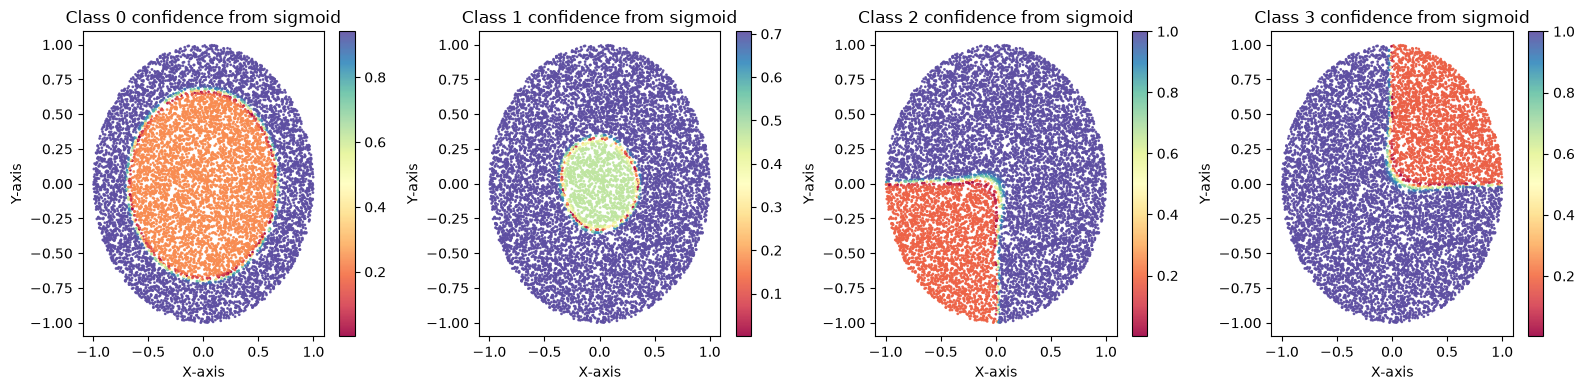

In [94]:
# plot sigmoid
plot_sigmoid_2D(model, data=multilabel_hypersphere_data, num_points_per_dim=100, output_dim=(2,2), seed=42)


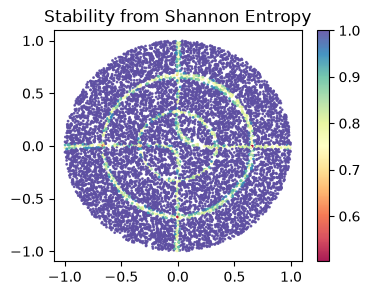

Mean Stability: 0.9833378791809082


In [95]:
plot_stability_2D(stab, data=multilabel_hypersphere_data, num_points_per_dim=100, output_dim=(2,2))

In [62]:
# generate new dataset and compute per-class F1
pt, lab = next(iter(multilabel_hypersphere_data(2, (2,2), 1000, batch_size=1000, seed=123)))
pt = pt.to(device)
with torch.no_grad():
    logits = model(pt)
    probs = torch.sigmoid(logits).cpu().numpy()
labels = lab.numpy().astype(int)

thresholds = find_best_thresholds(probs, labels)  # (sum(output_dim),)
preds = (probs > thresholds).astype(int)

f1_per_class = np.array([f1_score(labels[:, i], preds[:, i], zero_division=0) for i in range(labels.shape[1])])
print("F1 per class:", f1_per_class)

F1 per class: [0.99082569 0.99943407 0.99590164 0.98418972]


In [96]:
model, stab, cat_all = train_model(42, (16,64,128), n_epochs=30, batch_size=100, amount_data=1000,
                                                      data=multilabel_hypersphere_data, cat100=True, input_dim=2, output_dim=(2,2),
                                                        num_points_per_dim=100, history_limit = 100)

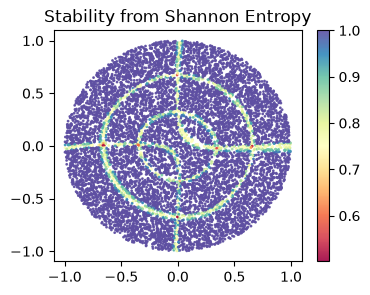

Mean Stability: 0.9786402583122253


In [97]:
plot_stability_2D(stab, data=multilabel_hypersphere_data, num_points_per_dim=100, output_dim=(2,2))

F1 scores per class:
Class 0: F1 score = 0.9872
Class 1: F1 score = 0.9939
Class 2: F1 score = 0.9950
Class 3: F1 score = 0.9900
Best thresholds per class: [0.45 0.5  0.5  0.45]


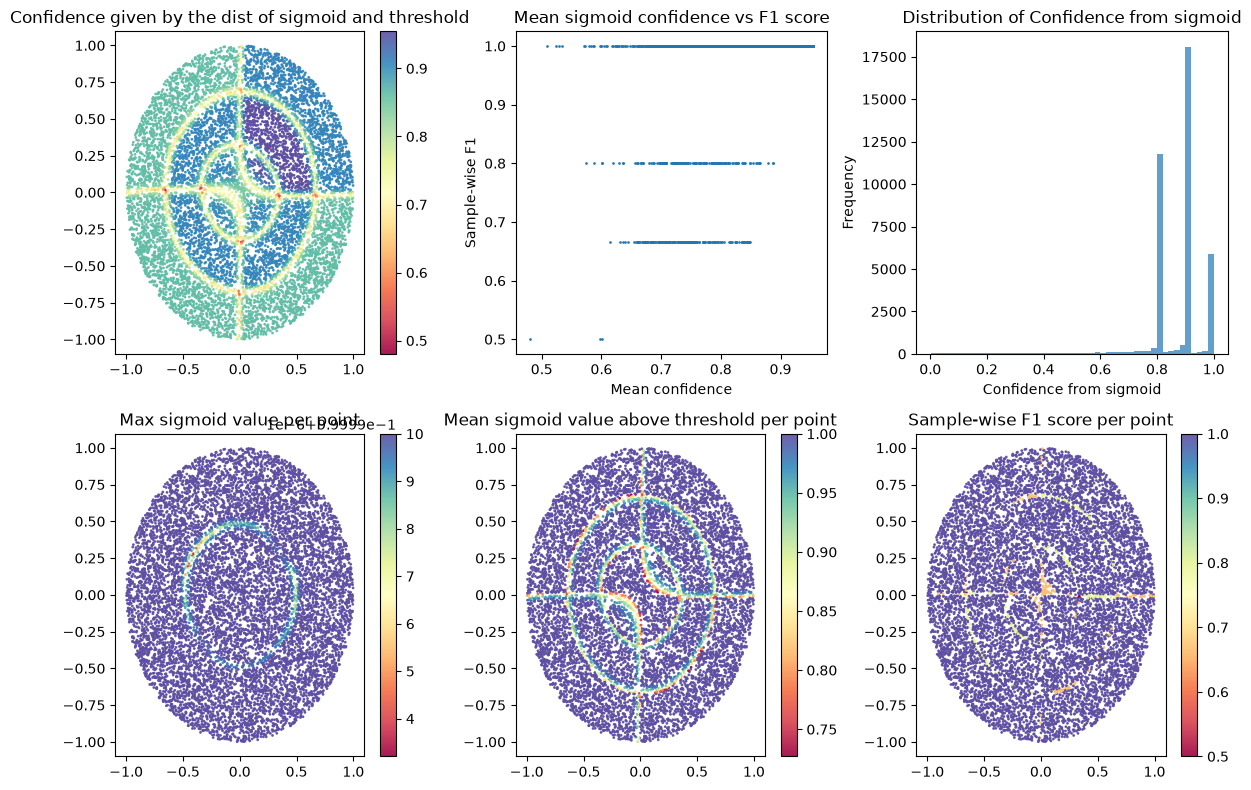

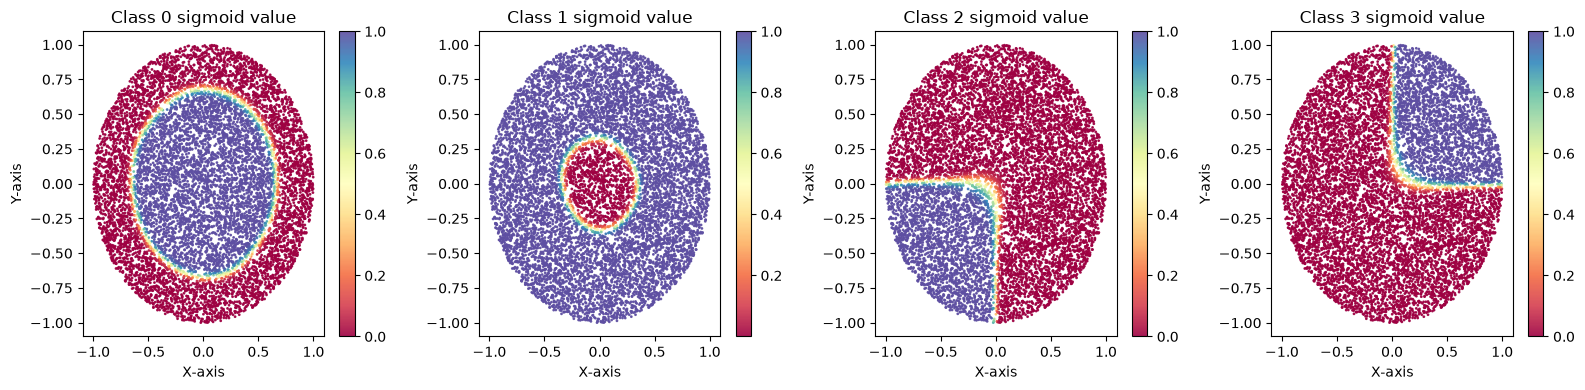

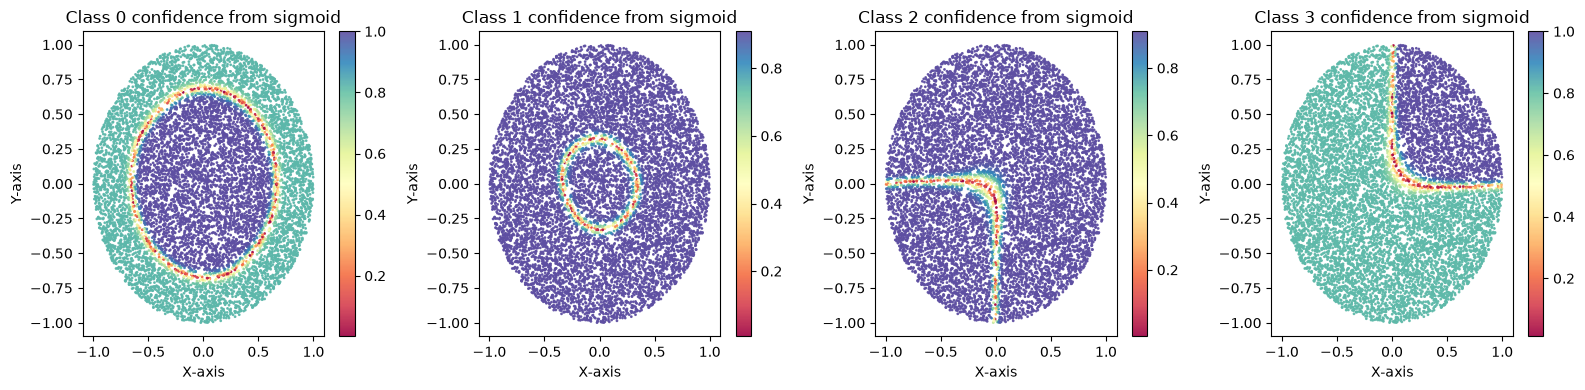

In [98]:
# plot sigmoid
plot_sigmoid_2D(model, data=multilabel_hypersphere_data, num_points_per_dim=100, output_dim=(2,2), seed=42)
